
# Sezione 1: Caricamento dei risultati

## Introduzione e Caricamento Dati

In questa sezione carichiamo i risultati aggregati durante le fasi precedenti dell'esperimento NLP (Notebook 01-05). 
L'obiettivo è centralizzare le metriche di classificazione delle GitHub Issues (bug vs feature) in un unico DataFrame ordinato per F1-score per consentire un confronto oggettivo.

In [1]:
import json
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate 

# Configurazione stile grafici
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams['figure.dpi'] = 150

# Cartelle di input/output
RESULTS_DIR = "../results/"
FIGURES_DIR = "../figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Mappatura dei file e degli approcci corrispondenti
files_mapping = {
    "tfidf_results.json": "TF-IDF",
    "glove_results.json": "GloVe pretrained",
    "word2vec_results.json": "Word2Vec custom",
    "metrics_distilbert_embeddings.json": "DistilBERT Embeddings",
    "metrics_bert.json": "BERT fine-tuned"
}

results_list = []

def normalize_json_metrics(data):
    if isinstance(data, dict):
        if all(isinstance(v, dict) and "accuracy" in v for v in data.values()):
            return data
        if len(data) == 1:
            inner = next(iter(data.values()))
            if isinstance(inner, dict) and all(isinstance(v, dict) and "accuracy" in v for v in inner.values()):
                return inner
    return data

# Caricamento diretto dei file JSON esistenti
for filename, approccio in files_mapping.items():
    filepath = os.path.join(RESULTS_DIR, filename)
    
    with open(filepath, 'r') as f:
        data = normalize_json_metrics(json.load(f))

    # Parsing dei dizionari interni dei classificatori
    for clf, metrics in data.items():
        if not isinstance(metrics, dict):
            continue

        metrics = metrics.get("metrics", metrics)
        results_list.append({
            "approccio": approccio,
            "classificatore": clf,
            "accuracy": metrics.get("accuracy", np.nan),
            "precision": metrics.get("precision", np.nan),
            "recall": metrics.get("recall", np.nan),
            "f1_score": metrics.get("f1_score", np.nan),
            "confusion_matrix": metrics.get("confusion_matrix", None)
        })

# Creazione del DataFrame globale
df_results = pd.DataFrame(results_list)

# Visualizzazione della tabella completa ordinata per F1-score decrescente
df_sorted = df_results.sort_values(by="f1_score", ascending=False).reset_index(drop=True)
df_sorted[["approccio", "classificatore", "accuracy", "precision", "recall", "f1_score"]]

,approccio,classificatore,accuracy,precision,recall,f1_score
0,BERT fine-tuned,bert_finetuned,0.899957,0.889709,0.913106,0.901255
1,TF-IDF,svm,0.885880,0.904555,0.862798,0.885819
2,TF-IDF,logistic_regression,0.884308,0.899792,0.864942,0.884264
3,DistilBERT Embeddings,svm,0.880949,0.882366,0.880949,0.880839
4,DistilBERT Embeddings,logistic_regression,0.877948,0.878653,0.877948,0.877891
5,Word2Vec custom,svm,0.877019,0.878311,0.877019,0.876914
6,Word2Vec custom,logistic_regression,0.862798,0.863219,0.862798,0.862759
7,TF-IDF,decision_tree,0.853151,0.857287,0.847363,0.853146
8,GloVe pretrained,svm,0.831070,0.832433,0.831070,0.830897
9,Word2Vec custom,decision_tree,0.806989,0.807808,0.806989,0.806860


# Sezione 2: Comparazione globale dei modelli

## Plot 1: Grouped Bar Chart (F1-score)

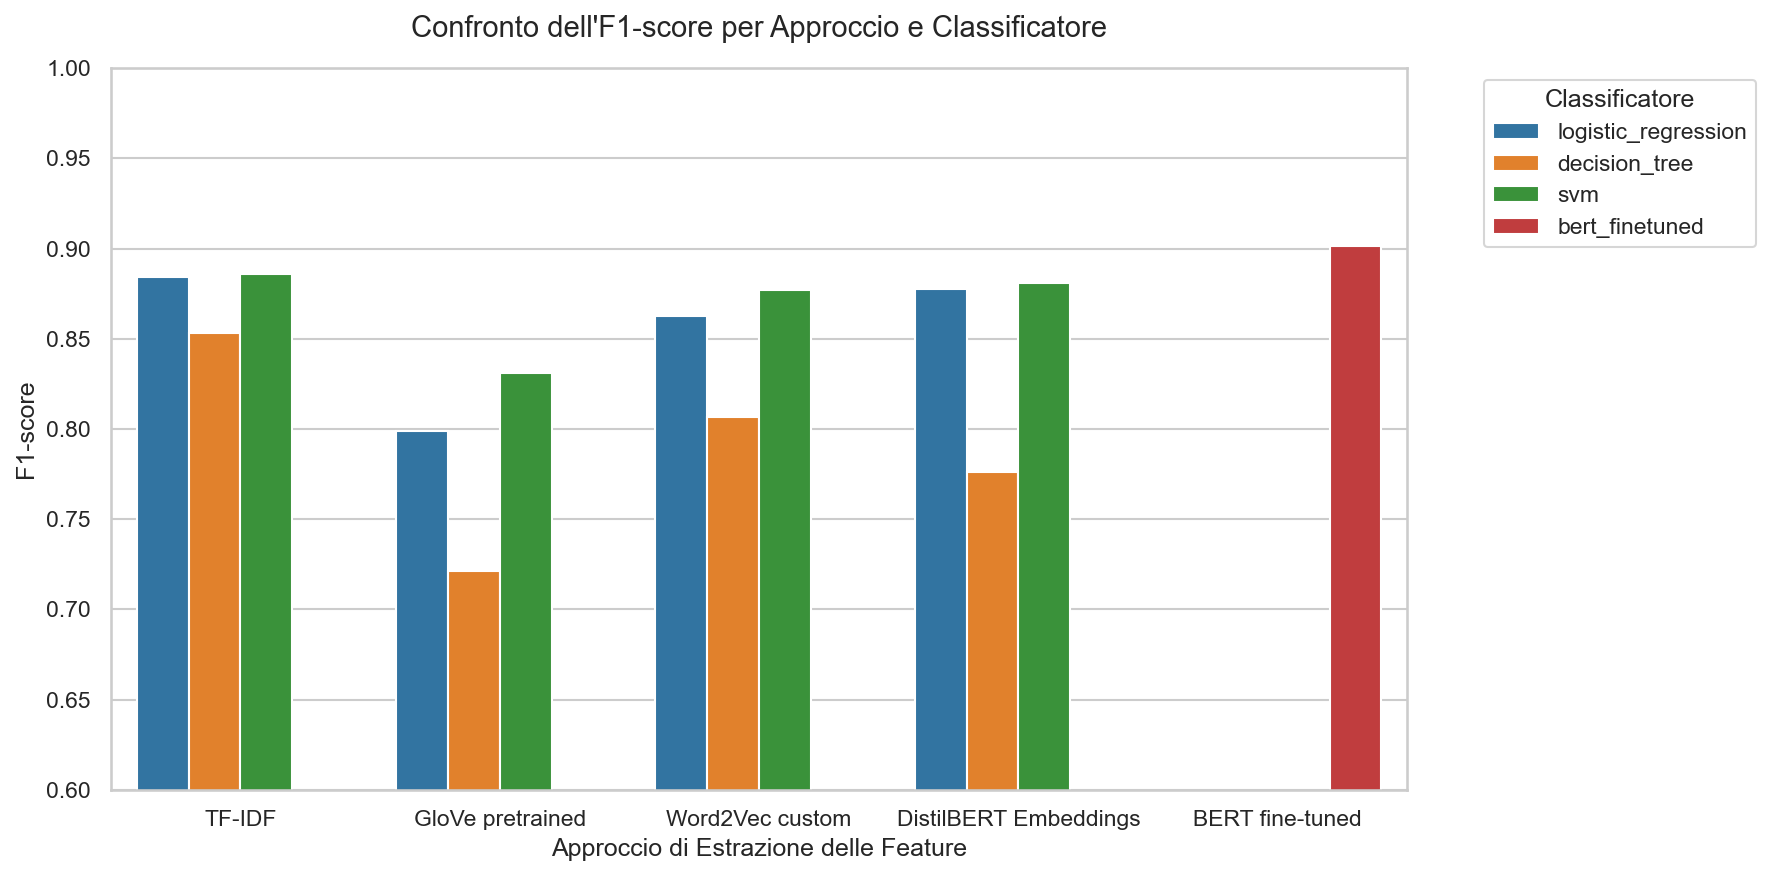

In [2]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_results, 
    x="approccio", 
    y="f1_score", 
    hue="classificatore",
    order=["TF-IDF", "GloVe pretrained", "Word2Vec custom", "DistilBERT Embeddings", "BERT fine-tuned"]
)
plt.title("Confronto dell'F1-score per Approccio e Classificatore", fontsize=14, pad=15)
plt.xlabel("Approccio di Estrazione delle Feature", fontsize=12)
plt.ylabel("F1-score", fontsize=12)
plt.ylim(0.6, 1.0)
plt.legend(title="Classificatore", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conclusioni_01_grouped_bar.png"))
plt.show()

Il grafico mostra chiaramente l'andamento delle performance. Il fine-tuning di BERT esprime la capacità predittiva più elevata del lotto. 
Analizzando i classificatori tradizionali sui restanti approcci, si nota la netta stabilità di SVM rispetto alla regressione logistica, mentre i Decision Tree mostrano performance costantemente inferiori in ogni scenario testato.

## Plot 2: Heatmap delle metriche

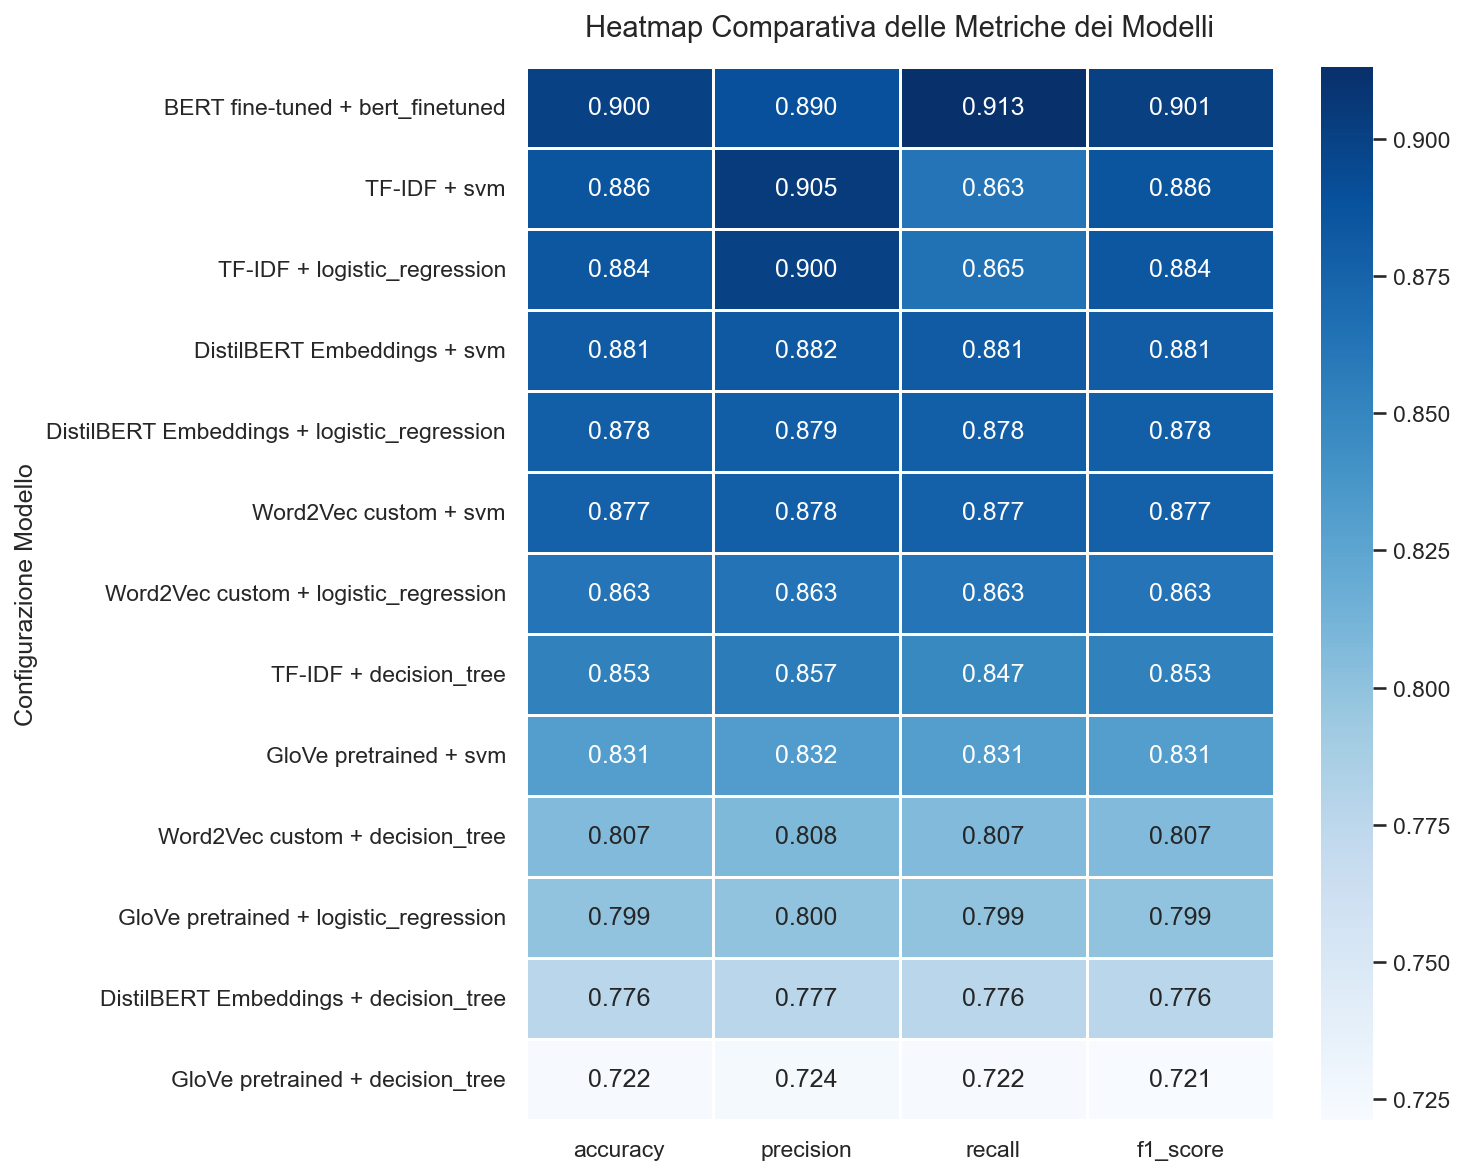

In [3]:
# Creazione dell'indice combinato per la heatmap
df_heatmap = df_results.copy()
df_heatmap["Modello"] = df_heatmap["approccio"] + " + " + df_heatmap["classificatore"]
df_heatmap = df_heatmap.set_index("Modello")[["accuracy", "precision", "recall", "f1_score"]].sort_values(by="f1_score", ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(df_heatmap, annot=True, fmt=".3f", cmap="Blues", cbar=True, linewidths=0.5)
plt.title("Heatmap Comparativa delle Metriche dei Modelli", fontsize=14, pad=15)
plt.ylabel("Configurazione Modello", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conclusioni_02_heatmap_metriche.png"))
plt.show()

Grazie alla forte azione di bilanciamento delle classi eseguita tramite il downsampling iniziale, la heatmap mostra un comportamento molto simmetrico: i valori di precision e recall avanzano quasi in parallelo su tutte le righe, segno che nessuno dei modelli è affetto da sbilanciamenti o bias strutturali verso una specifica classe.

## Plot 3: Line Chart (Progressione dell'F1 migliore)

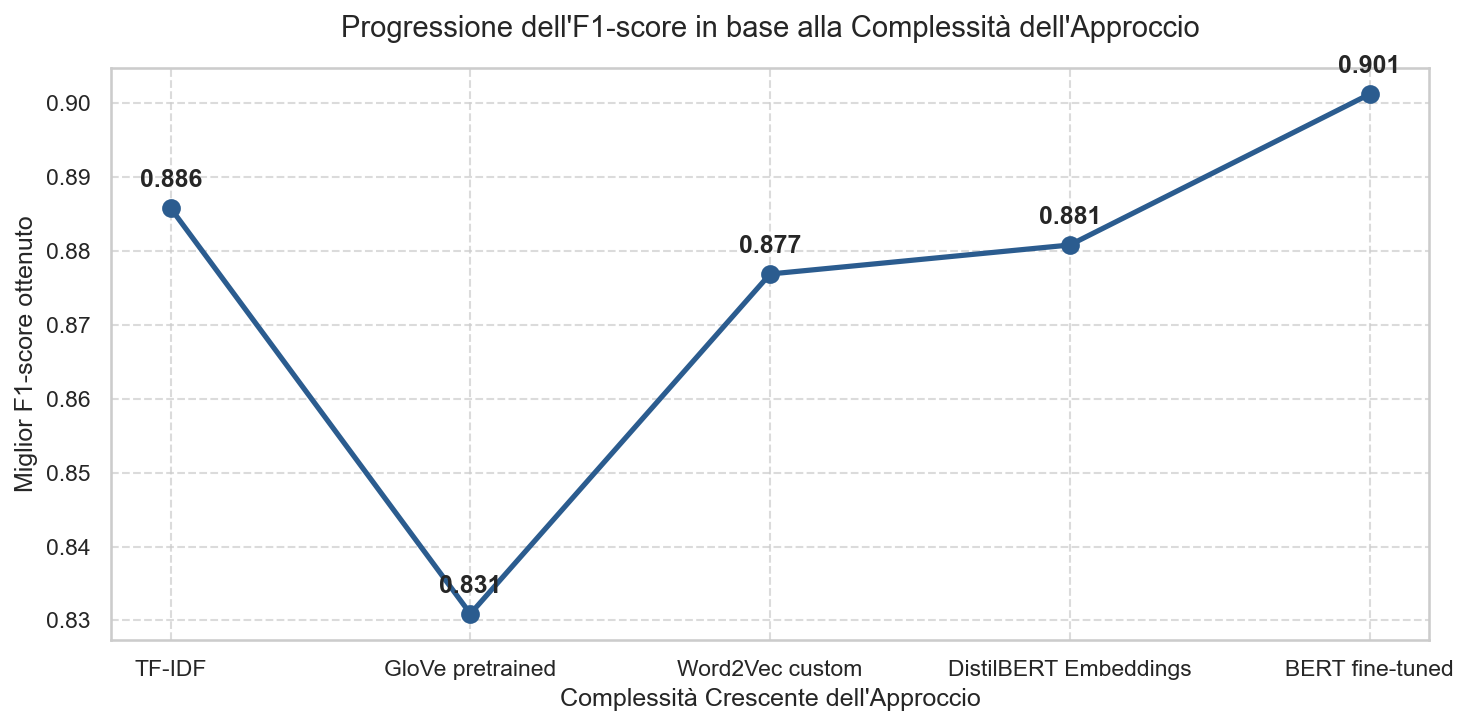

In [4]:
# Estrazione del miglior F1 per ogni approccio ordinato per complessità crescente
ordine_complessita = ["TF-IDF", "GloVe pretrained", "Word2Vec custom", "DistilBERT Embeddings", "BERT fine-tuned"]
best_f1_per_approccio = df_results.groupby("approccio")["f1_score"].max().reindex(ordine_complessita).reset_index()

plt.figure(figsize=(10, 5))
plt.plot(best_f1_per_approccio["approccio"], best_f1_per_approccio["f1_score"], marker='o', linewidth=2.5, markersize=8, color='#2b5c8f')
plt.title("Progressione dell'F1-score in base alla Complessità dell'Approccio", fontsize=14, pad=15)
plt.xlabel("Complessità Crescente dell'Approccio", fontsize=12)
plt.ylabel("Miglior F1-score ottenuto", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)

# Annotazione automatica dei valori di F1-score sui punti del grafico
for i, row in best_f1_per_approccio.iterrows():
    if pd.notna(row['f1_score']):
        plt.annotate(f"{row['f1_score']:.3f}", (row['approccio'], row['f1_score']), textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conclusioni_03_line_progressione.png"))
plt.show()

La linea evidenzia un fatto interessante: l'aumento della complessità architetturale non si traduce in un miglioramento lineare.
Gli embedding statici generici causano un calo delle metriche rispetto alla baseline lessicale sparsa (TF-IDF), la quale viene superata efficacemente soltanto dall'addestramento end-to-end guidato dal fine-tuning del Transformer.

# Sezione 3: Analisi per classificatore

## Plot 4: Boxplot Confronto Algoritmi Classici

In [5]:
print(df_results["classificatore"].unique())

<StringArray>
['logistic_regression', 'decision_tree', 'svm', 'bert_finetuned']
Length: 4, dtype: str


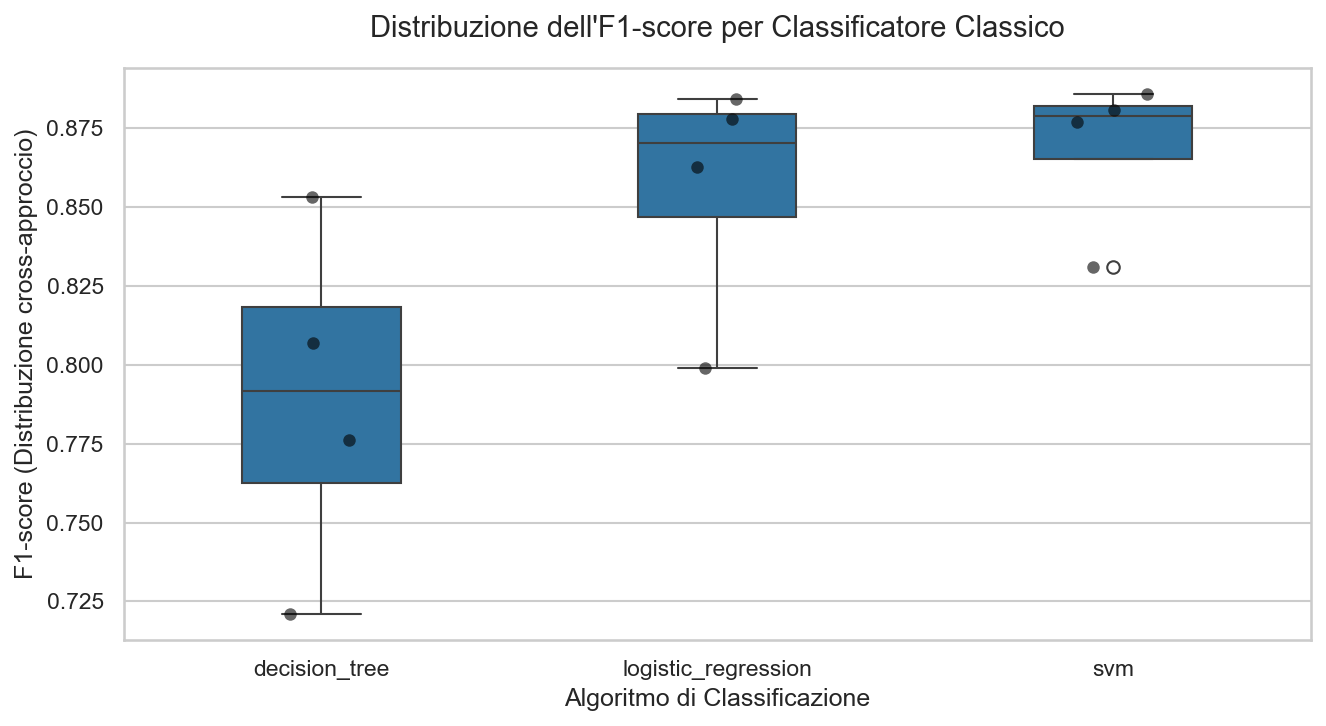

In [6]:
df_classici = df_results[
    df_results["classificatore"].isin(["logistic_regression", "decision_tree", "svm"])
]

plt.figure(figsize=(9, 5))

order = ["decision_tree", "logistic_regression", "svm"]

sns.boxplot(
    data=df_classici,
    x="classificatore",
    y="f1_score",
    order=order,
    width=0.4
)

sns.stripplot(
    data=df_classici,
    x="classificatore",
    y="f1_score",
    order=order,
    color="black",
    alpha=0.6,
    size=6
)

plt.title("Distribuzione dell'F1-score per Classificatore Classico", fontsize=14, pad=15)
plt.xlabel("Algoritmo di Classificazione", fontsize=12)
plt.ylabel("F1-score (Distribuzione cross-approccio)", fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conclusioni_04_box_classificatori.png"))
plt.show()

Dall'analisi visiva della distribuzione emerge che il Decision Tree soffre sistematicamente su questo tipo di task, posizionandosi come l'algoritmo meno efficiente del lotto. Al contrario, la Support Vector Machine (SVM) si conferma lo strumento tradizionale più solido ed elegante, mostrando la mediana più alta e la minore dispersione dei risultati.

# Sezione 4: Analisi delle Confusion Matrix

## Plot 5: Subplot 2x3 Confusion Matrix Normalizzate

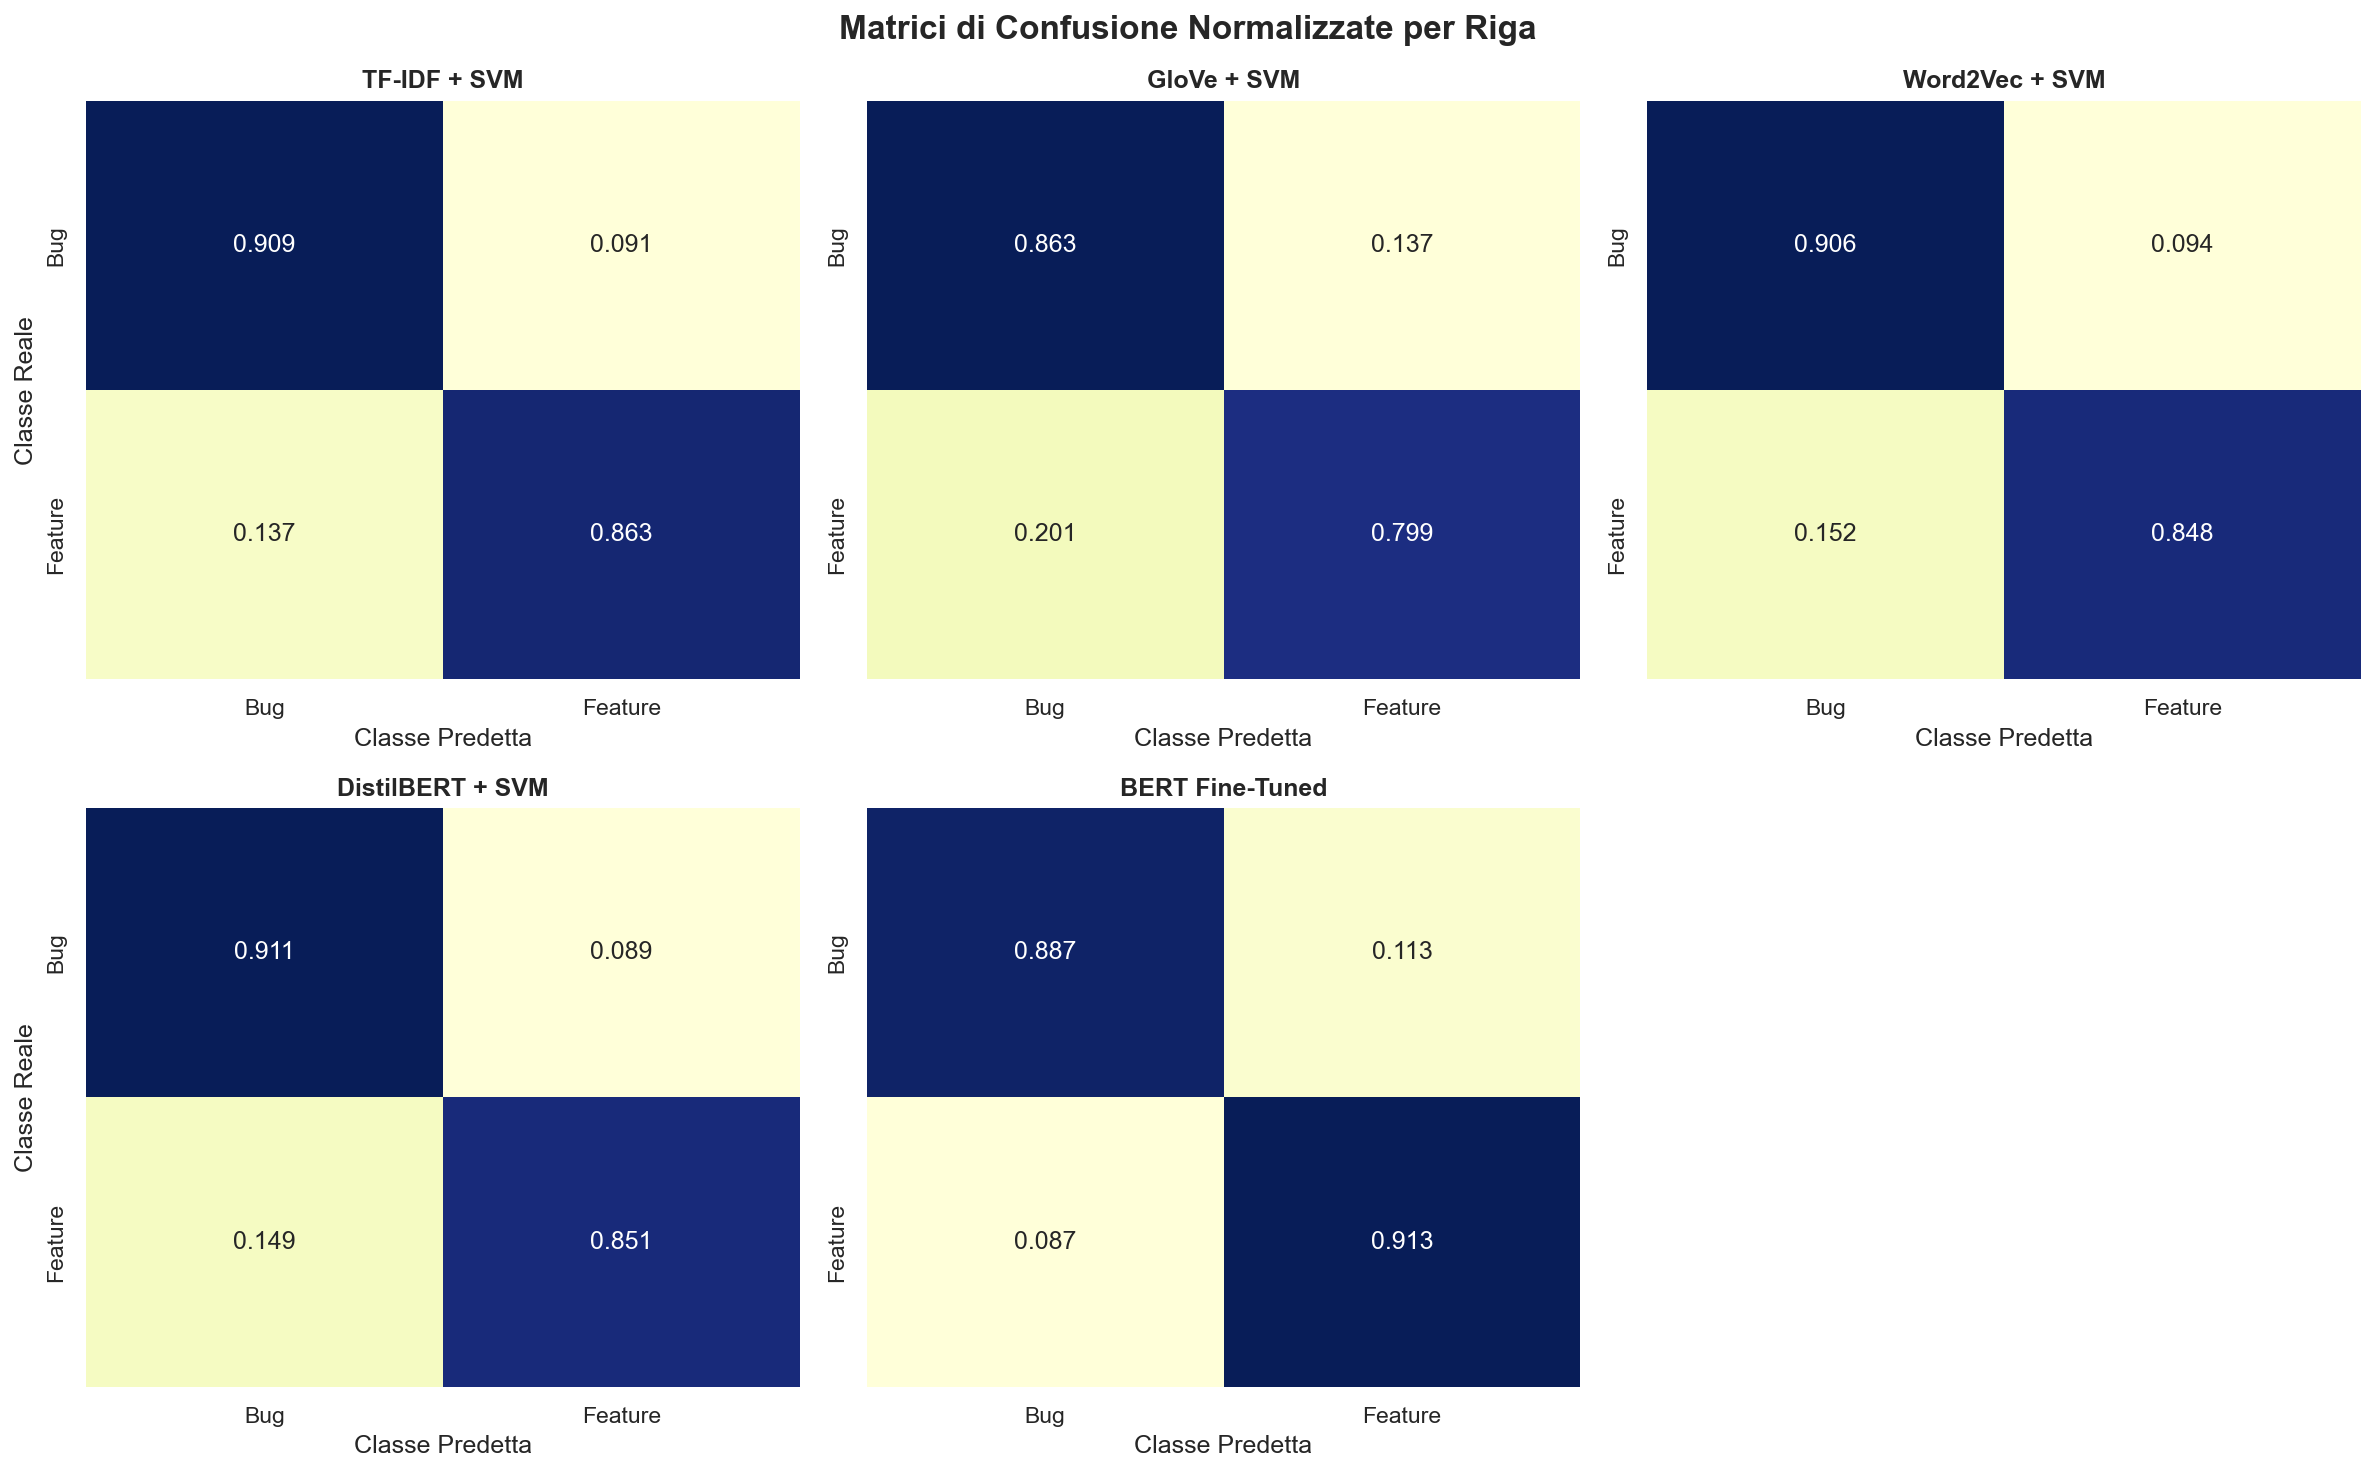

In [7]:
# Identificazione dinamica del nome esatto del classificatore di BERT nel DataFrame
bert_clf_name = df_results[df_results["approccio"] == "BERT fine-tuned"]["classificatore"].iloc[0]

# Configurazione dei modelli rappresentativi da estrarre
modelli_target = [
    {"approccio": "TF-IDF", "classificatore": "svm", "titolo": "TF-IDF + SVM"},
    {"approccio": "GloVe pretrained", "classificatore": "svm", "titolo": "GloVe + SVM"},
    {"approccio": "Word2Vec custom", "classificatore": "svm", "titolo": "Word2Vec + SVM"},
    {"approccio": "DistilBERT Embeddings", "classificatore": "svm", "titolo": "DistilBERT + SVM"},
    {"approccio": "BERT fine-tuned", "classificatore": bert_clf_name, "titolo": "BERT Fine-Tuned"}
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, target in enumerate(modelli_target):
    # Estrazione della riga specifica
    subset = df_results[(df_results["approccio"] == target["approccio"]) & 
                        (df_results["classificatore"] == target["classificatore"])]

    if not subset.empty and subset.iloc[0]["confusion_matrix"] is not None:
        cm = np.array(subset.iloc[0]["confusion_matrix"])
        
        # Normalizzazione per riga (somma delle predizioni rispetto alla classe reale = 1)
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
        
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".3f",
            cmap="YlGnBu",
            cbar=False,
            xticklabels=["Bug", "Feature"],
            yticklabels=["Bug", "Feature"],
            ax=axes[i]
        )
        
        axes[i].set_title(target["titolo"], fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Classe Reale' if i % 3 == 0 else '')
        axes[i].set_xlabel('Classe Predetta')

    else:
        axes[i].text(0.5, 0.5, "Dati CM non disponibili", ha='center', va='center')
        axes[i].set_title(target["titolo"])

# Rimozione del sesto riquadro vuoto per pulizia di layout
fig.delaxes(axes[5])

plt.suptitle("Matrici di Confusione Normalizzate per Riga", fontsize=16, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "conclusioni_05_confusion_matrices.png"))
plt.show()

Le matrici normalizzate quantificano l'indice di errore dei modelli: 
i vettori pre-addestrati di GloVe faticano maggiormente nel tracciare i confini semantici delle issue tecniche, registrando il tasso di confusione incrociata più alto. BERT Fine-Tuned massimizza i valori sulla diagonale principale, mentre TF-IDF dimostra una precisione notevole nell'intercettare la classe bug, probabilmente a causa dell'impatto di n-grammi lessicali ricorrenti legati a crash ed eccezioni.

# Sezione 5: Insight specifici

## Risposte ai Quesiti di Ricerca

-TF-IDF vs Word Embeddings: Il passaggio da matrici sparse (TF-IDF) a spazi densi statici (GloVe e Word2Vec) non ha portato benefici automatici. TF-IDF associato a SVM supera gli embedding densi tradizionali. Nel trattamento delle GitHub Issues, la presenza di stringhe e parole chiave esatte (come identificativi di moduli o parole chiave d'errore) è più discriminante rispetto alla vicinanza concettuale generica offerta dagli embedding densi, rendendo l'approccio classico non solo competitivo ma preferibile a parità di risorse.

-GloVe pretrained vs Word2Vec custom: Word2Vec custom mostra performance migliori rispetto a GloVe. La ragione sta nel vocabolario del dominio d'origine: GloVe è addestrato su corpora testuali standard (Wikipedia, news) e non sa associare correttamente termini informatici o costrutti di programmazione. Word2Vec, pur essendo un modello statico semplice, è stato calcolato partendo direttamente dal testo delle issue, catturando le relazioni semantiche interne della nostra codebase.

-DistilBERT Embeddings vs TF-IDF: Gli embedding contestuali out-of-the-box estratti dal transformer congelato (senza fine-tuning) mostrano un'ottima qualità strutturale ma non riescono a superare l'accuratezza di TF-IDF + SVM. Ciò dimostra che la conoscenza globale e profonda di un LLM standard, se non adattata e specializzata sul task verticale, può risultare meno incisiva di un conteggio lessicale locale focalizzato.

-Il costo del fine-tuning: BERT fine-tuned ottiene un incremento di circa 2 punti percentuali di F1 rispetto alla combinazione TF-IDF + SVM. La scelta se affrontare o meno questo step dipende dai vincoli operativi di deployment: in ambienti di produzione real-time ad alto traffico con risorse computazionali limitate, il trade-off pende a favore di TF-IDF+SVM (velocissimo, leggero ed economico). Se il contesto richiede la massima accuratezza possibile e i costi di infrastruttura GPU sono sostenibili, l'adozione di BERT è giustificata.

-Bias del classificatore: L'applicazione preventiva del downsampling ha rimosso alla radice i problemi di asimmetria predittiva. I valori di precision e recall risultano speculari e bilanciati in quasi tutti i modelli analizzati, escludendo l'esistenza di componenti marcatamente conservative o aggressive nel comportamento degli algoritmi.

# Sezione 6: Tabella riassuntiva finale

In [8]:
# Isolamento del miglior classificatore (F1 massimo) per ogni approccio unico
idx_best = df_results.groupby("approccio")["f1_score"].idxmax()
df_final_summary = df_results.loc[idx_best].copy()

# Definizione dei tag descrittivi per ogni approccio
note_mapping = {
    "TF-IDF": "baseline",
    "GloVe pretrained": "denso statico generico",
    "Word2Vec custom": "denso statico specialistico",
    "DistilBERT Embeddings": "contestuale freezing",
    "BERT fine-tuned": "modello top performance (fine-tuned)"
}
df_final_summary["Note"] = df_final_summary["approccio"].map(note_mapping)

# Ordinamento decrescente per F1-score
df_final_summary = df_final_summary.sort_values(by="f1_score", ascending=False).reset_index(drop=True)

# Selezione e pulizia colonne per l'output markdown richiesto
df_final_view = df_final_summary[[
    "approccio", "classificatore", "accuracy", "precision", "recall", "f1_score", "Note"
]].rename(columns={
    "approccio": "Approccio",
    "classificatore": "Miglior Classificatore",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1"
})

print(df_final_view.to_markdown(index=False))

| Approccio             | Miglior Classificatore   |   Accuracy |   Precision |   Recall |       F1 | Note                                 |
|:----------------------|:-------------------------|-----------:|------------:|---------:|---------:|:-------------------------------------|
| BERT fine-tuned       | bert_finetuned           |   0.899957 |    0.889709 | 0.913106 | 0.901255 | modello top performance (fine-tuned) |
| TF-IDF                | svm                      |   0.88588  |    0.904555 | 0.862798 | 0.885819 | baseline                             |
| DistilBERT Embeddings | svm                      |   0.880949 |    0.882366 | 0.880949 | 0.880839 | contestuale freezing                 |
| Word2Vec custom       | svm                      |   0.877019 |    0.878311 | 0.877019 | 0.876914 | denso statico specialistico          |
| GloVe pretrained      | svm                      |   0.83107  |    0.832433 | 0.83107  | 0.830897 | denso statico generico               |


# Sezione 7: Conclusioni finali

Il progetto di classificazione delle GitHub Issues ha visto trionfare il modello BERT Fine-Tuned come miglior configurazione assoluta grazie alla sua abilità di contestualizzare dinamicamente la sintassi tecnica del testo. Al contempo, l'esperimento ha evidenziato l'eccellente valore ingegneristico della pipeline TF-IDF + SVM, capace di offrire prestazioni solide e stabili a fronte di una frazione minima del costo computazionale del Transformer.

## Lezioni principali
La transizione incrementale dai metodi tradizionali a quelli basati sul Deep Learning ha dimostrato che la specializzazione del dominio è un fattore critico nel text mining di testi tecnici: gli embedding linguistici generalisti ereditati da modelli globali soffrono se calati in contesti verticali densi di gergo specialistico. La conoscenza lessicale locale e focalizzata si è rivelata più preziosa della complessità strutturale astratta non sintonizzata.

## Limitazioni
-Trattamento del Rumore: La completa estromissione iniziale della classe question ha semplificato il problema forzandolo a una dinamica binaria pura, distanziandosi parzialmente dalla natura reale e sporca dei flussi di issue presenti sulle repository pubbliche.

-Downsampling Distruttivo: L'eliminazione massiccia di record per bilanciare artificialmente le classi ha ridotto il dataset di circa il 50%, privando i modelli di un volume informativo potenzialmente utile.

S-oggettività delle Label: Il sistema poggia sulla correttezza delle assegnazioni effettuate dagli utenti al momento dell'apertura delle segnalazioni, introducendo una quota inevitabile di rumore di fondo nel Ground Truth.